<a href="https://colab.research.google.com/github/ajaypandey2402/ICL-ML-Specialization/blob/main/lab_reflection_bear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
# PACKAGE
# Run this cell first once to load the dependancies.
%matplotlib inline
import numpy as np
from numpy.linalg import norm, inv
from numpy import transpose
#from readonly.bearNecessities import * - Not possible to import the library from the course

In [68]:
verySmallNumber = 1e-14
# Gram-Schmidt function in general form
def gsBasis(A):
    B = np.array(A, dtype=np.float64)
    for i in range(B.shape[1]):
        for j in range(i):
            B[:, i] = B[:, i] - B[:, i] @ B[:, j] * B[:, j]
        if la.norm(B[:, i]) > verySmallNumber:
            B[:, i] = B[:, i] / la.norm(B[:, i])
        else:
            B[:, i] = np.zeros_like(B[:, i])
    return B

In [69]:
# GRADED FUNCTION
# You should edit this cell.

# In this function, you will return the transformation matrix T,
# having built it out of an orthonormal basis set E that you create from Bear's Basis
# and a transformation matrix in the mirror's coordinates TE.
def build_reflection_matrix(bearBasis) : # The parameter bearBasis is a 2×2 matrix that is passed to the function.
    # Use the gsBasis function on bearBasis to get the mirror's orthonormal basis.
    E = gsBasis(bearBasis)
    # Write a matrix in component form that performs the mirror's reflection in the mirror's basis.
    # Recall, the mirror operates by negating the last component of a vector.
    # Replace a,b,c,d with appropriate values
    TE = np.array([[1, 0],
                   [0, -1]])
    # Combine the matrices E and TE to produce your transformation matrix.
    T = E @ TE @ transpose(E)
    # Finally, we return the result. There is no need to change this line.
    return T


EVERYTHING THAT IS UNDER THIS LINE IS JUST TO TRY TO DRAW THE BEAR WHICH WAS IN THE ORIGINAL ICL'S COURSE'S LAB. BUT IT IS NOT PERFECT AND DOESN'T LOOK LIKE A BEAR MUCH

In [70]:
# IMPROVISED BEARNECESSITIES
# Fur colours
bear_white = '#E0E0E0'
bear_black = '#212121'

# Bear's polygons' coordinates
bear_white_fur = np.array([
    [-1.0, -1.2, -1.5, -1.8, -1.6, -1.2, -0.8, -0.5, -0.4, -0.6, -0.9, -1.0],
    [ 2.0,  2.8,  3.2,  2.5,  1.8,  1.2,  1.0,  1.4,  2.2,  2.8,  2.5,  2.0]
])

bear_black_fur = np.array([
    [-1.6, -1.7, -1.5, -1.3, -1.4, -1.1, -0.9, -0.7, -0.8, -1.1],
    [ 2.3,  2.6,  2.9,  2.6,  2.1,  1.5,  1.3,  1.7,  2.2,  2.4]
])

bear_face = np.array([
    [-1.3, -1.2, -1.0, -0.8, -0.7, -0.9, -1.1, -1.3],
    [ 2.2,  2.4,  2.5,  2.3,  2.0,  1.8,  1.9,  2.2]
])

In [71]:
# IMPROVISED MIRROR DRAWING FUNCTION AND COORDINATE SYSTEM
def draw_mirror(bearBasis):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Normalised mirror's basis
    E = gsBasis(bearBasis)

    # Draw mirror's plane (along E[:, 0])
    mirror_line = np.linspace(-5, 5, 100)
    if E[0, 0] != 0:
        slope = E[1, 0] / E[0, 0]
        ax.plot(mirror_line, slope * mirror_line, color='cyan', linewidth=3, label='Mirror Surface', zorder=0)
    else:
        ax.axvline(0, color='cyan', linewidth=3, label='Mirror Surface', zorder=0)

    ax.set_xlim(-4, 4)
    ax.set_ylim(-1, 5)
    ax.set_aspect('equal')
    ax.grid(True, which='both', color='gray', linestyle='--', alpha=0.5)
    ax.set_facecolor('#1e1e1e') # Dark background for contrast
    ax.set_title("Bear and his Reflection", color='white', fontsize=14)
    return ax

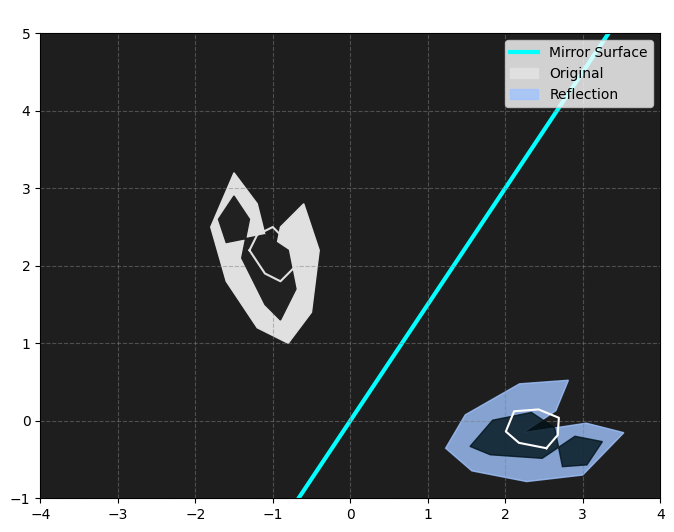

In [72]:
# DRAWING OF THE BEAR AND IT'S REFLECTION
bearBasis = np.array([
    [1,   -1],
    [1.5,  2]
])

# Reflection matrix
T = build_reflection_matrix(bearBasis)

# Apply matrix T to bear's polygons
reflected_bear_white_fur = T @ bear_white_fur
reflected_bear_black_fur = T @ bear_black_fur
reflected_bear_face = T @ bear_face

# Graphic scene with a mirror
ax = draw_mirror(bearBasis)

# Draw original
ax.fill(bear_white_fur[0], bear_white_fur[1], color=bear_white, zorder=1, label='Original')
ax.fill(bear_black_fur[0], bear_black_fur[1], color=bear_black, zorder=2)
ax.plot(bear_face[0], bear_face[1], color=bear_white, zorder=3)

# Draw reflection
ax.fill(reflected_bear_white_fur[0], reflected_bear_white_fur[1], color='#A0C4FF', alpha=0.8, zorder=1, label='Reflection')
ax.fill(reflected_bear_black_fur[0], reflected_bear_black_fur[1], color='#001219', alpha=0.8, zorder=2)
ax.plot(reflected_bear_face[0], reflected_bear_face[1], color='white', zorder=3)

ax.legend(loc='upper right')
plt.show()